## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## 2. Load the Dataset

In [2]:
df = pd.read_csv("CarPrice_Assignment.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


### 2.1 Display the First Five Records

In [3]:
print("First 5 records:")
print(df.head())

First 5 records:
   car_ID  symboling                   CarName  ... citympg highwaympg    price
0       1          3        alfa-romero giulia  ...      21         27  13495.0
1       2          3       alfa-romero stelvio  ...      21         27  16500.0
2       3          1  alfa-romero Quadrifoglio  ...      19         26  16500.0
3       4          2               audi 100 ls  ...      24         30  13950.0
4       5          2                audi 100ls  ...      18         22  17450.0

[5 rows x 26 columns]


### 2.2 Display the Last Five Records

In [4]:
print("\nLast 5 records:")
print(df.tail())


Last 5 records:
     car_ID  symboling          CarName  ... citympg highwaympg    price
200     201         -1  volvo 145e (sw)  ...      23         28  16845.0
201     202         -1      volvo 144ea  ...      19         25  19045.0
202     203         -1      volvo 244dl  ...      18         23  21485.0
203     204         -1        volvo 246  ...      26         27  22470.0
204     205         -1      volvo 264gl  ...      19         25  22625.0

[5 rows x 26 columns]


### 2.3 Display the Number of Rows and Columns

In [5]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(205, 26)


### 2.4 Display Dataset Information


In [6]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 

### 2.5 Identify Numerical and Categorical Attributes

In [7]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical attributes:")
print(list(numerical))

Numerical attributes:
['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


In [8]:
categorical = df.select_dtypes(include=['object']).columns
print("\nCategorical attributes:")
print(list(categorical))


Categorical attributes:
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


### 2.6 Check for Missing Values

In [9]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


### 2.7 Check for Duplicate Records

In [10]:
print("\nNumber of duplicate records:")
print(df.duplicated().sum())


Number of duplicate records:
0


### 2.8 Generate Descriptive Statistics

In [11]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
           car_ID   symboling   wheelbase  ...     citympg  highwaympg         price
count  205.000000  205.000000  205.000000  ...  205.000000  205.000000    205.000000
mean   103.000000    0.834146   98.756585  ...   25.219512   30.751220  13276.710571
std     59.322565    1.245307    6.021776  ...    6.542142    6.886443   7988.852332
min      1.000000   -2.000000   86.600000  ...   13.000000   16.000000   5118.000000
25%     52.000000    0.000000   94.500000  ...   19.000000   25.000000   7788.000000
50%    103.000000    1.000000   97.000000  ...   24.000000   30.000000  10295.000000
75%    154.000000    2.000000  102.400000  ...   30.000000   34.000000  16503.000000
max    205.000000    3.000000  120.900000  ...   49.000000   54.000000  45400.000000

[8 rows x 16 columns]


In [12]:
print(df.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


### Remove Irrelevant Attributes

In [13]:
df = df.drop('car_ID', axis=1)

In [14]:
print(df.isnull().sum())

symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


## Encode Categorical Variables

In [15]:
# Fill numerical missing values with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded dataset:")
print(df_encoded.head())

Encoded dataset:
   symboling  wheelbase  ...  fuelsystem_spdi  fuelsystem_spfi
0          3       88.6  ...            False            False
1          3       88.6  ...            False            False
2          1       94.5  ...            False            False
3          2       99.8  ...            False            False
4          2       99.4  ...            False            False

[5 rows x 190 columns]


## Separate Independent and Dependent Variables


In [17]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (205, 189)
y shape: (205,)


## Distribution of Car Prices

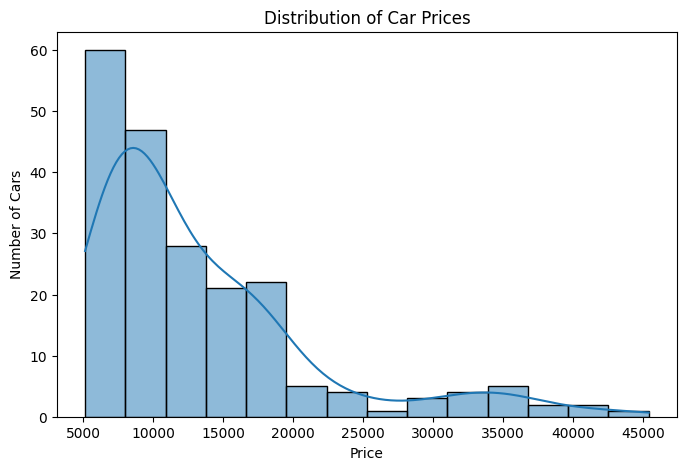

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(df['price'], kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

## Horsepower vs Price

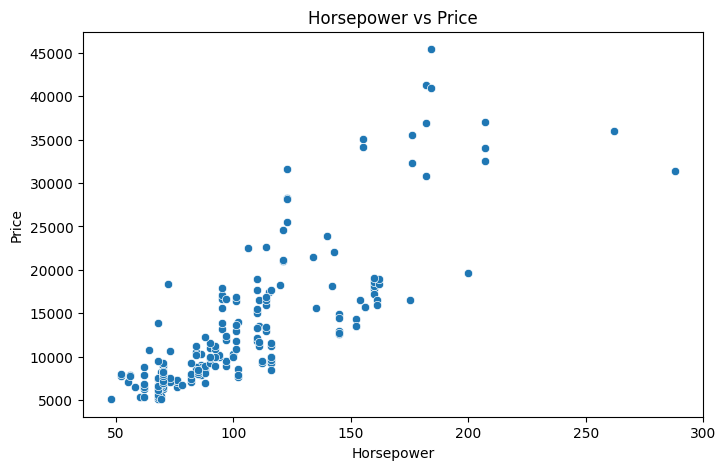

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df['horsepower'], y=df['price'])

plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

## Engine Size vs Price

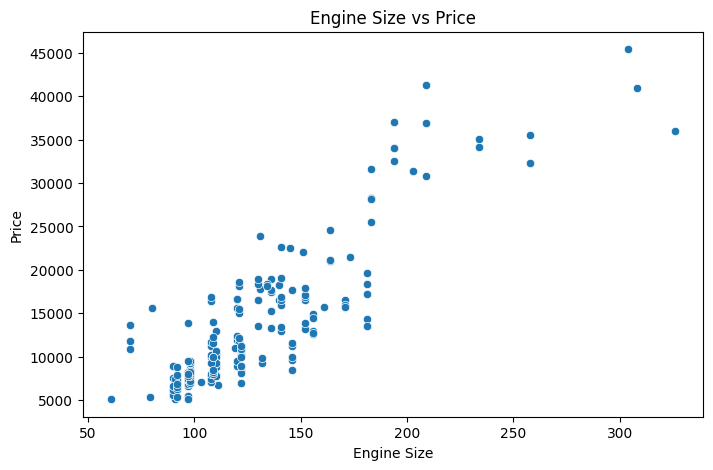

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df['enginesize'], y=df['price'])

plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

## Curb Weight vs Price

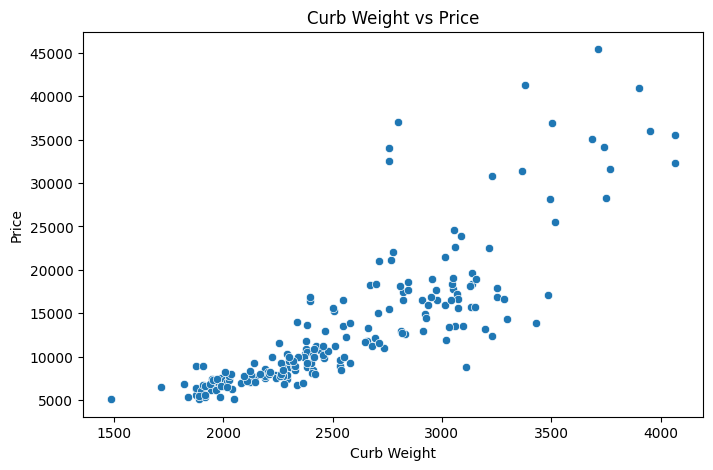

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df['curbweight'], y=df['price'])

plt.title("Curb Weight vs Price")
plt.xlabel("Curb Weight")
plt.ylabel("Price")
plt.show()

## Correlation Matrix and Heatmap

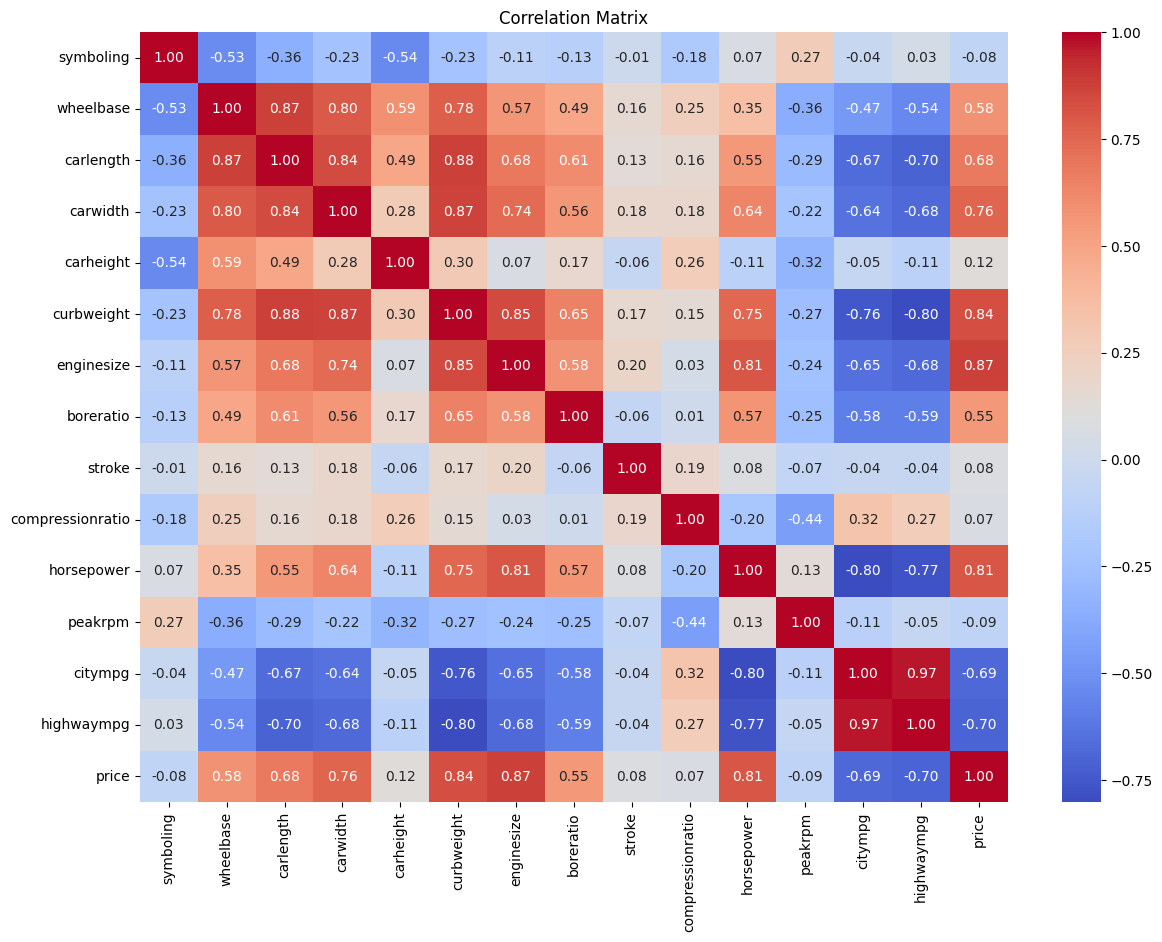

In [22]:
plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [23]:
price_corr = correlation['price'].sort_values(ascending=False)

print("Correlation with Price:")
print(price_corr)

Correlation with Price:
price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (164, 189)
Testing data: (41, 189)


In [28]:
model = LinearRegression()

## Train the Regression Model

In [29]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


## Predict Car Prices

In [30]:
y_pred = model.predict(X_test)
print("Predicted prices:")
print(y_pred)

Predicted prices:
[13907.571516   20592.93292802 13012.62517671  7686.26414981
 27128.65418376  6820.11772042  8821.01991394  9198.09023861
 15336.59901222 12531.69557782 14375.9244769   4441.31711078
 15463.4429998   8329.5010725  38257.32525235  8498.79596862
 -8895.02065627 13186.01125748 17753.15760613 16139.14886092
 13963.33631572 16956.56193395 12008.67593275  4543.92766941
 15775.99910526 15072.93799904 12646.8556423  12994.88693286
  7264.56979386 11184.22135753 26021.45671425  8687.31218947
  7519.47901986 17997.67084215  4372.41559884 27426.01475529
 17777.61673204 13296.58736951 12282.35833519 16991.07049048
 12556.43390244]


In [31]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0     30760.000     13907.571516
1     17859.167     20592.932928
2      9549.000     13012.625177
3     11850.000      7686.264150
4     28248.000     27128.654184
5      7799.000      6820.117720
6      7788.000      8821.019914
7      9258.000      9198.090239
8     10198.000     15336.599012
9      7775.000     12531.695578


## Evaluate the Regression Model

In [32]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4177.295631354042


In [33]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 41547027.85288088


In [34]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 6445.698399155896


In [35]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.47371533157380974


In [36]:
print("\nModel Evaluation")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


Model Evaluation
-------------------------
MAE  : 4177.295631354042
MSE  : 41547027.85288088
RMSE : 6445.698399155896
R²   : 0.47371533157380974


## Actual Price vs Predicted Price

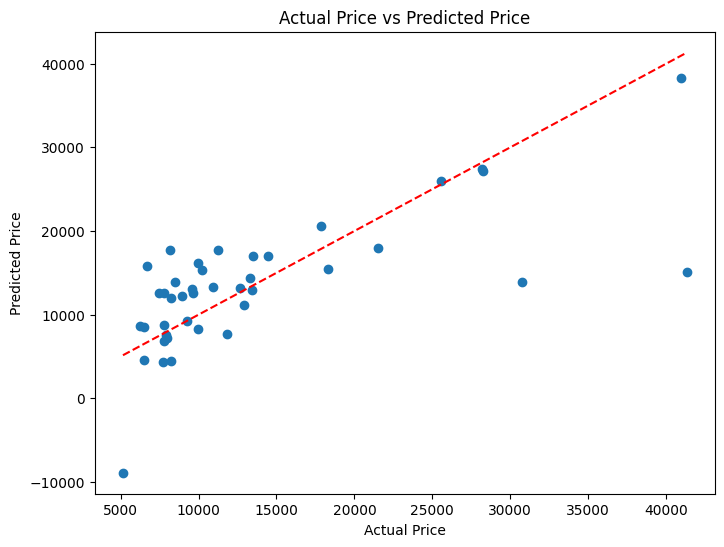

In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Prediction Errors / Residual Plot

In [38]:
residuals = y_test - y_pred

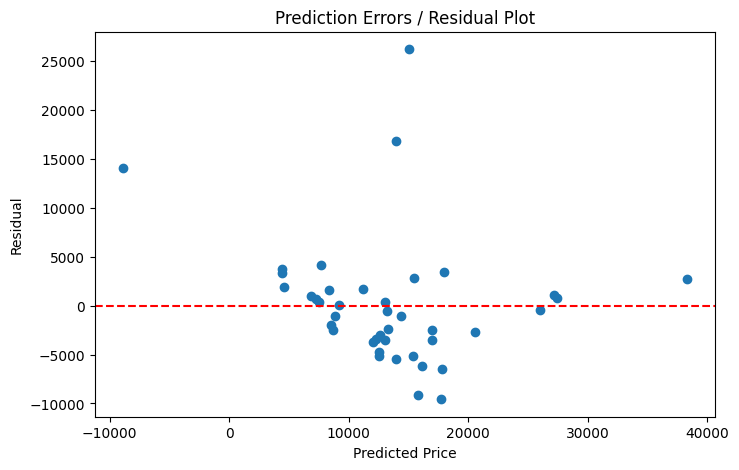

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Prediction Errors / Residual Plot")

plt.show()

## Prediction of a New Car


In [40]:
# Take the first car as a template
new_car = df.iloc[0].copy()

# Change important car specifications
new_car['enginesize'] = 130
new_car['horsepower'] = 110
new_car['curbweight'] = 2500
new_car['citympg'] = 28
new_car['highwaympg'] = 34

In [41]:
new_car_df = pd.DataFrame([new_car])

In [42]:
new_car_encoded = pd.get_dummies(new_car_df, drop_first=True)

In [43]:
new_car_encoded = new_car_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

## Predicted Price

In [44]:
new_price = model.predict(new_car_encoded)

print("Predicted price of the new car:", new_price[0])

Predicted price of the new car: 25168.360268399818


In [45]:
print("======================================")
print("     CAR PRICE PREDICTION MODEL")
print("======================================")

print("\nDataset Size:", df.shape)

print("\nModel Evaluation:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

print("\nPredicted Price of New Car:")
print(new_price[0])

print("======================================")

     CAR PRICE PREDICTION MODEL

Dataset Size: (205, 25)

Model Evaluation:
MAE  : 4177.295631354042
MSE  : 41547027.85288088
RMSE : 6445.698399155896
R²   : 0.47371533157380974

Predicted Price of New Car:
25168.360268399818
